# Feature-space coverage of the generator pools

Accuracy benchmarks ask whether synthetic data helps a model. Coverage asks a narrower question first: do the generator pools produce series whose statistical summaries land near those of real series at all? If a whole region of real behaviour has no synthetic neighbour, no amount of pretraining on that corpus can teach it. This page walks through the frozen twelve-feature schema, the distance-based scoring protocol, the results across the six M4 frequencies, and the one frequency where the pools fall short. Every number is loaded from committed benchmark summaries; the scripts that produced them are listed at the end.

::: {.callout-important}
## Summary

- **Twelve native features** (`native_v1`) are defined for every one of the 100,000 M4 training series under declared period and window recipes, and they respond in the expected direction to controlled changes in dependence, seasonality, spikes, level shifts, and variance shifts.
- **M4, Yearly to Daily:** the balanced and pretraining pools cover 56–88% of fresh held-out real queries at the real-calibrated radius, against real-to-real baselines of 80–91%. No M4 panel other than Hourly shows a material gap over three generation seeds and four query groups.
- **M4 Hourly is the largest gap:** 1–2% coverage against a 91% baseline, replicated on 288 distinct real queries. The missing combination is a daily cycle with slow level and amplitude changes; trend strength alone carries about half the remaining distance.
- **Independent panels change the picture:** on Monash tourism quarterly and Australian weather daily the pools also fall 35 points or more short, and hospital monthly is 27 points short, while tourism yearly and traffic weekly are covered as well as M4. Gaps are panel-specific, with strong regular seasonality the recurring theme.
- **Configuring existing generators** closes most of the M4 Hourly gap (67% coverage) but transfers only partly to an independent traffic panel (19%). A moderated seasonal corpus, added to the balanced pool at equal candidate count, raises coverage on all five quarterly and monthly panels tested, three of them held out, by 3 to 32 points. That corpus ships as the opt-in `seasonal_pool()` preset; a pre-declared test on four more panels passes on M1 monthly, is neutral on M4, and shows no benefit on intermittent data, so the default pools are unchanged.
:::

## What is measured

`compute_features` returns one row of twelve summaries per series: spectral entropy, trend and seasonal strength from a classical decomposition, four autocorrelation summaries, spike and lumpiness, the largest level and variance shift between adjacent windows, and the number of mean crossings. The definitions are frozen as `native_v1`; the seasonal period and window width are extraction parameters that you declare per panel, not part of the schema.

The example below extracts features for a small hourly panel and compares two synthetic sources in that space with `compare_feature_coverage`. It needs no network access, so the reference here is itself synthetic; the benchmarks further down use real M4 and traffic data.

In [ ]:
import polars as pl

from synforecast import (
    SynSet,
    compare_feature_coverage,
    compute_features,
    interpretable_pool,
    pretraining_pool,
)


def complete_series(panel):
    # The IoT failure preset emits missing values on purpose; coverage needs finite series.
    return panel.filter(pl.col("y").is_finite().all().over("unique_id"))


reference = complete_series(
    SynSet(
        pretraining_pool(min_length=240, max_length=240, freq="h", seed=1, engine="polars")
    ).generate(n_series_per_generator=2, n_jobs=1)
)
candidates = complete_series(
    SynSet(
        interpretable_pool(min_length=240, max_length=240, freq="h", seed=2, engine="polars")
    ).generate(n_series_per_generator=2, n_jobs=1)
)

features = compute_features(reference, seasonal_period=24, window_size=24)
features.head(5)

unique_id,spectral_entropy,trend_strength,seasonal_strength,acf1,x_acf10,diff1_acf1,seas_acf1,spike,lumpiness,max_level_shift,max_var_shift,crossing_points
cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""0""",0.909885,0.053936,0.090303,0.024578,0.009891,-0.528855,0.035754,0.000033,0.069112,0.740444,0.742725,109.0
"""1""",0.900983,0.038642,0.072626,0.112323,0.054037,-0.358184,0.038263,0.000029,0.069164,0.664928,1.025231,103.0
"""10""",0.131633,0.773312,0.001031,0.978992,4.987978,0.616899,-0.829164,0.000002,0.022209,1.909348,0.531178,10.0
"""100""",0.297085,0.91732,0.926322,0.767445,1.690312,0.469553,0.803405,6.8625e-8,0.000817,0.770652,0.115337,66.0
"""101""",0.808997,0.098544,0.183417,0.42952,0.298913,-0.166853,0.493803,0.000022,0.094264,0.747801,0.983541,84.0


In [ ]:
result = compare_feature_coverage(
    reference, {"balanced": candidates}, seasonal_period=24, window_size=24, missing="drop"
)["balanced"]
print(f"features used: {len(result.features_used)}; constant dropped: {result.constant_features_dropped}")
print(f"real series retained: {len(result.real_diagnostics.retained_ids)} of {result.real_diagnostics.n_input}")
print(f"PCA(2) explained variance: {sum(result.explained_variance):.0%}")
print(f"uncovered real series (grid): {result.uncovered_real_series_fraction:.0%}")

features used: 12; constant dropped: ()
real series retained: 106 of 106
PCA(2) explained variance: 66%
uncovered real series (grid): 40%


The `CoverageResult` reports which features were used, how many series each side retained, and grid-based miscoverage in a two-dimensional PCA map fitted on the reference alone. The map is a convenient picture, but two dimensions keep only 54–84% of the feature variance on M4 panels, so the benchmarks score coverage on **all standardized features** and use the map only for illustration.

::: {.callout-note}
## How the benchmarks score coverage

1. Fit the feature mean and scale on 64 real **reference** series only. Synthetic data never shifts the space.
2. For each held-out real **query**, find its nearest synthetic series and its nearest real candidate in standardized Euclidean distance.
3. Calibrate a radius as the 90th percentile of nearest distances from 32 separate real **calibration** queries to the real candidates.
4. Coverage is the fraction of queries whose nearest synthetic series lies within that radius. The **real baseline** is the same fraction using real candidates, and bounds what any corpus of that size can reach.
5. Synthetic and real candidates are matched one-to-one in count and length, so candidate density cannot favour either side.

Queries are always disjoint from the fitting and calibration series, criteria are declared before results are inspected, and repeated settings use fresh queries rather than the ones that informed a design. Coverage is conditional on the twelve features, the distance, and the radius; Manhattan distance and single-feature omissions are reported as sensitivity checks.
:::

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("benchmarks/data")
if not DATA.exists():
    DATA = Path("../../benchmarks/data")


def load(name):
    return json.loads((DATA / name / "summary.json").read_text())


COLORS = {
    "balanced_pool": "#2a78d6",
    "pretraining_pool": "#eb6834",
    "synforecast_mar": "#1baf7a",
    "real": "#0b0b0b",
}
LABELS = {
    "balanced_pool": "balanced pool",
    "pretraining_pool": "pretraining pool",
    "synforecast_mar": "random MAR",
    "real": "real baseline",
}

## Coverage across frequencies

The cross-frequency benchmark samples 640 training series per M4 frequency (all 359 for Weekly), forms four disjoint groups of 64 fresh queries, and scores the unchanged `interpretable_pool` (labelled "balanced pool" in the benchmark artifacts, its name at the time), `pretraining_pool`, and a random MAR corpus over three generation seeds with 240 matched candidates each. Hourly comes from the earlier fresh-split validation, which used the same protocol.

In [ ]:
cross = load("feature_coverage_cross_frequency")
hourly = load("feature_coverage_hourly_splits")

rows = []
for group, panel in cross["panels"].items():
    agg = panel["summary"]
    rows.append(
        {"frequency": group}
        | {name: agg[name]["full"]["coverage"]["median"][1] for name in COLORS if name != "real"}
        | {
            f"{name}_range": tuple(v[1] for v in agg[name]["full"]["coverage"]["min_max"])
            for name in COLORS
            if name != "real"
        }
        | {"real": agg["balanced_pool"]["full"]["real_baseline_coverage"]["median"][1]}
    )
agg = hourly["existing_summary"]
rows.append(
    {"frequency": "Hourly"}
    | {name: agg[name]["full"]["coverage"]["median"][1] for name in COLORS if name != "real"}
    | {
        f"{name}_range": tuple(v[1] for v in agg[name]["full"]["coverage"]["min_max"])
        for name in COLORS
        if name != "real"
    }
    | {"real": agg["balanced_pool"]["full"]["real_baseline_coverage"]["median"][1]}
)
frequencies = pd.DataFrame(rows).set_index("frequency")
frequencies[["balanced_pool", "pretraining_pool", "synforecast_mar", "real"]].rename(
    columns=LABELS
).style.format("{:.1%}")

,balanced pool,pretraining pool,random MAR,real baseline
frequency,,,,
Yearly,81.2%,79.7%,9.4%,85.2%
Quarterly,87.5%,85.9%,34.4%,90.6%
Monthly,70.3%,72.7%,14.8%,85.9%
Weekly,61.7%,57.8%,1.6%,79.7%
Daily,56.2%,51.6%,0.0%,81.2%
Hourly,0.8%,1.6%,0.0%,90.6%


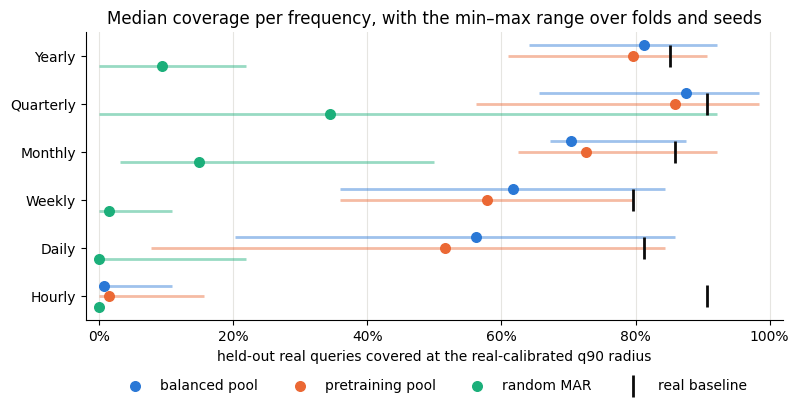

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = range(len(frequencies))
offsets = {"balanced_pool": -0.22, "pretraining_pool": 0.0, "synforecast_mar": 0.22}
for name, offset in offsets.items():
    lows = [r[0] for r in frequencies[f"{name}_range"]]
    highs = [r[1] for r in frequencies[f"{name}_range"]]
    yy = [i + offset for i in y]
    ax.hlines(yy, lows, highs, color=COLORS[name], linewidth=2, alpha=0.45)
    ax.scatter(frequencies[name], yy, color=COLORS[name], s=48, zorder=3, label=LABELS[name])
ax.scatter(
    frequencies["real"], list(y), marker="|", s=260, color=COLORS["real"], linewidth=2,
    zorder=4, label=LABELS["real"],
)
ax.set_yticks(list(y))
ax.set_yticklabels(frequencies.index)
ax.invert_yaxis()
ax.set_xlim(-0.02, 1.02)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_xlabel("held-out real queries covered at the real-calibrated q90 radius")
ax.set_title("Median coverage per frequency, with the min–max range over folds and seeds")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#e6e5e1")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4, frameon=False)
fig.subplots_adjust(bottom=0.24)
plt.show()

Each dot is the median over four query groups and three generation seeds; the bar behind it spans the twelve fold–seed pairs. Three things stand out.

- **Yearly and Quarterly are essentially covered.** The pools sit within a few points of what real candidates achieve. Monthly, Weekly, and Daily fall 5–20 points short, with Weekly flagged as a minor gap and Daily depending strongly on which real series are queried (two folds gap by more than 25 points, two by less than 10).
- **The two pools are interchangeable here.** They stay within five points of each other on every panel, so the meta-generators added by the pretraining pool do not buy coverage in this feature space. Random MAR is far behind everywhere except Quarterly.
- **Hourly is a different regime.** Coverage is 1–2% against a 91% baseline, and the twelve fold–seed pairs never exceed 16%. The rest of this page is about that gap.

### What covered queries look like

Coverage numbers summarize distances between feature vectors, so it is worth checking that a covered query actually resembles its nearest synthetic neighbour. The examples below are real M4 series from the first fold and first seed of the benchmark above, chosen at fixed rank percentiles (10th, 50th, 90th) of their distance to the balanced pool rather than for visual effect, and shown next to their nearest neighbour from each pool. Every series is standardized so that shape, not scale, is compared; the label gives the generator prototype and the standardized feature distance.

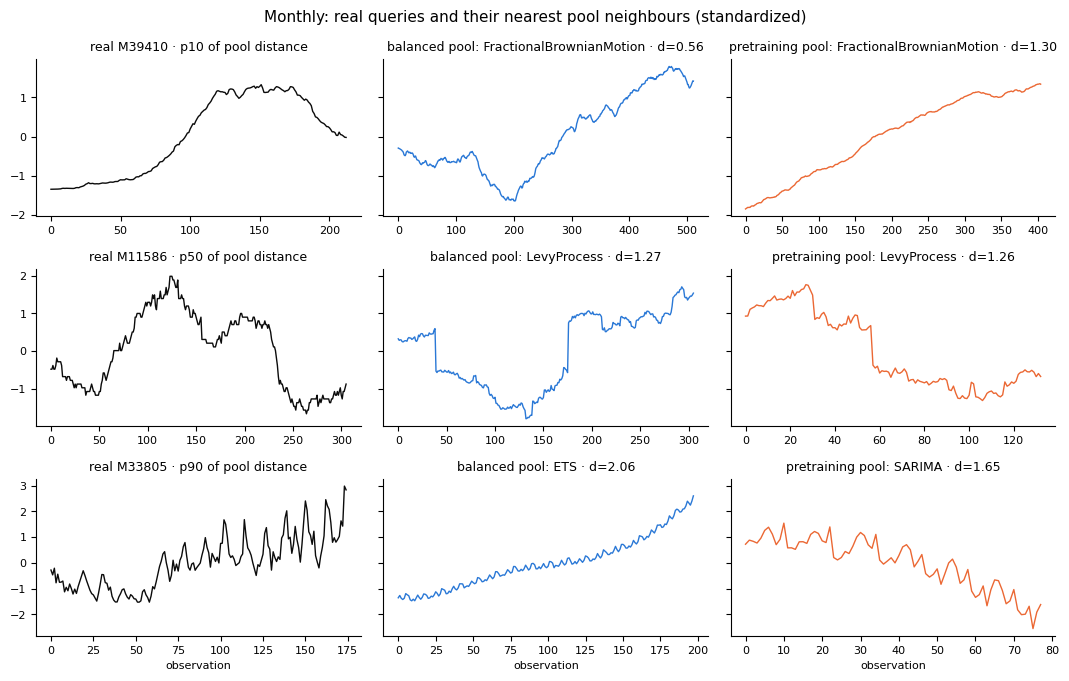

In [ ]:
examples = json.loads((DATA / "feature_coverage_examples" / "examples.json").read_text())
NEIGHBOUR_LABELS = LABELS | {
    "native_composition": "first-round composition",
    "targeted_composition": "targeted composition",
    "moderated_seasonal_composition": "moderated seasonal corpus",
}
NEIGHBOUR_COLORS = COLORS | {
    "native_composition": "#2a78d6",
    "targeted_composition": "#eb6834",
    "moderated_seasonal_composition": "#eb6834",
}


def standardized(values):
    values = pd.Series(values, dtype=float)
    scale = values.std()
    return (values - values.mean()) / scale if scale > 0 else values * 0


def plot_examples(panel_name, sources, title):
    panel = examples["panels"][panel_name]["examples"]
    fig, axes = plt.subplots(
        len(panel), len(sources) + 1, figsize=(3.6 * (len(sources) + 1), 2.3 * len(panel)),
        sharey="row", squeeze=False,
    )
    for row, example in enumerate(panel):
        ax = axes[row, 0]
        ax.plot(standardized(example["real_values"]).to_numpy(), color="#0b0b0b", linewidth=1)
        ax.set_title(
            f"real {example['real_id']} · p{int(example['rank_percentile_of_balanced_distance'] * 100)} of pool distance",
            fontsize=9,
        )
        for col, name in enumerate(sources, start=1):
            neighbour = example["neighbours"][name]
            ax = axes[row, col]
            ax.plot(standardized(neighbour["values"]).to_numpy(), color=NEIGHBOUR_COLORS[name], linewidth=1)
            prototype = neighbour["prototype"].split(":")[-1].replace("Generator", "")
            ax.set_title(f"{NEIGHBOUR_LABELS[name]}: {prototype} · d={neighbour['distance']:.2f}", fontsize=9)
    for ax in axes.flat:
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("observation", fontsize=8)
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


plot_examples(
    "Monthly", ["balanced_pool", "pretraining_pool"],
    "Monthly: real queries and their nearest pool neighbours (standardized)",
)

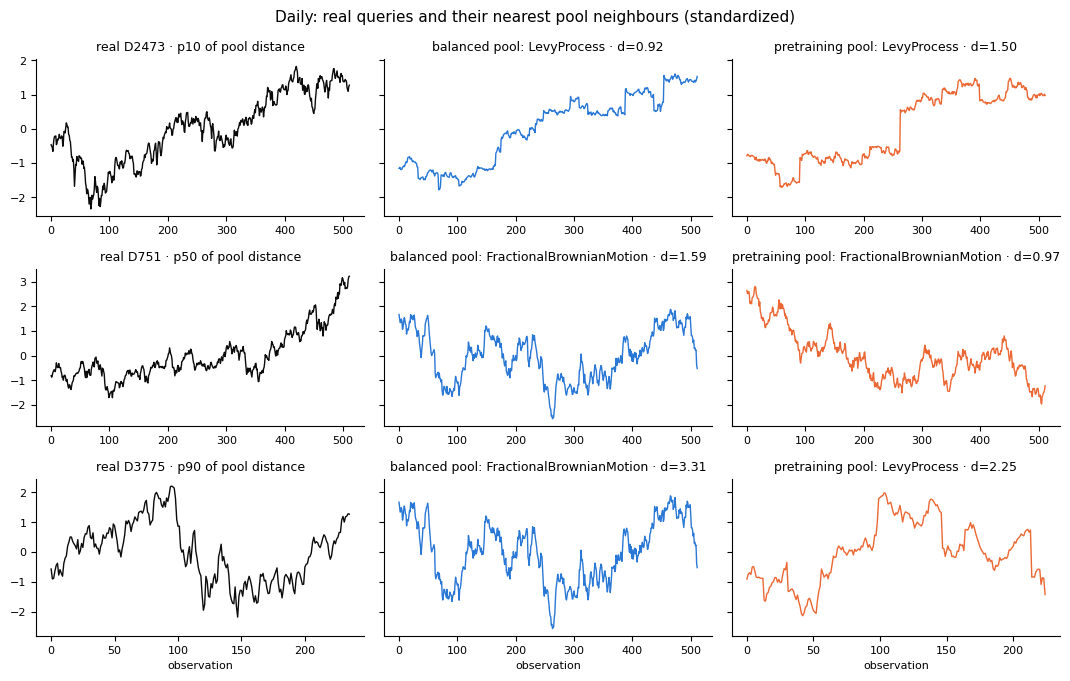

In [ ]:
plot_examples(
    "Daily", ["balanced_pool", "pretraining_pool"],
    "Daily: real queries and their nearest pool neighbours (standardized)",
)

The close and median queries resemble their neighbours: gradual or stepwise level movements are matched by fractional Brownian motion and Lévy-process series, which is why those two prototypes dominate the nearest-neighbour counts on Monthly and Daily. Neighbours are matched on the twelve features, not on the path itself, so lengths differ and the comparison is one of texture and level movement rather than exact shape.

The 90th-percentile queries show where the pools thin out. The Monthly query has irregular seasonal swings on a rising level; its nearest neighbours offer either the rise without the swings or the swings without the rise. The Daily query is shorter and drops sharply in level midway; its neighbours are rough random walks without such a break. These are the queries that the real baseline covers and the pools do not.

### Independent panels

M4 is one source, so each non-hourly frequency was also scored on a public Monash panel from another domain with the identical protocol: tourism demand (yearly and quarterly), hospital patient counts (monthly), San Francisco freeway occupancy (weekly), and Australian weather stations (daily). Hourly's independent panel is the traffic dataset used in the composition rounds below.

In [ ]:
third = load("feature_coverage_third_panels")
m4_balanced = frequencies["balanced_pool"]
third_rows = []
for group, panel in third["panels"].items():
    agg = panel["summary"]
    third_rows.append(
        {"frequency": f"{group} ({panel['source']['dataset']})"}
        | {name: agg[name]["full"]["coverage"]["median"][1] for name in COLORS if name != "real"}
        | {
            f"{name}_range": tuple(v[1] for v in agg[name]["full"]["coverage"]["min_max"])
            for name in COLORS
            if name != "real"
        }
        | {
            "real": agg["balanced_pool"]["full"]["real_baseline_coverage"]["median"][1],
            "balanced on M4": m4_balanced[group],
            "flag": "material" if panel["gap_flags"]["material_gap"] else ("minor" if panel["gap_flags"]["minor_gap"] else "none"),
        }
    )
third_panels = pd.DataFrame(third_rows).set_index("frequency")
third_panels[["balanced_pool", "pretraining_pool", "synforecast_mar", "real", "balanced on M4", "flag"]].rename(
    columns=LABELS
).style.format("{:.1%}", subset=["balanced pool", "pretraining pool", "random MAR", "real baseline", "balanced on M4"])

,balanced pool,pretraining pool,random MAR,real baseline,balanced on M4,flag
frequency,,,,,,
Yearly (tourism_yearly),82.8%,82.0%,18.8%,90.6%,81.2%,none
Quarterly (tourism_quarterly),46.9%,42.2%,19.5%,91.4%,87.5%,material
Monthly (hospital),57.8%,53.9%,31.2%,85.2%,70.3%,minor
Weekly (traffic_weekly),71.1%,70.3%,54.7%,84.4%,61.7%,none
Daily (weather),47.7%,51.6%,14.1%,85.2%,56.2%,material


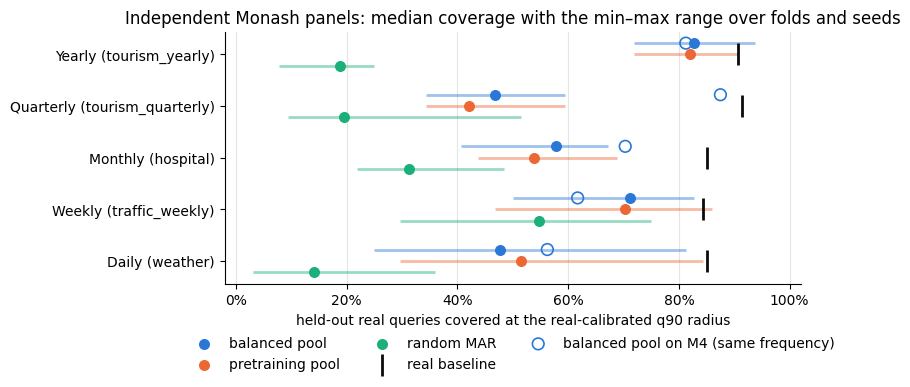

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.2))
y = range(len(third_panels))
for name, offset in offsets.items():
    lows = [r[0] for r in third_panels[f"{name}_range"]]
    highs = [r[1] for r in third_panels[f"{name}_range"]]
    yy = [i + offset for i in y]
    ax.hlines(yy, lows, highs, color=COLORS[name], linewidth=2, alpha=0.45)
    ax.scatter(third_panels[name], yy, color=COLORS[name], s=48, zorder=3, label=LABELS[name])
ax.scatter(
    third_panels["real"], list(y), marker="|", s=260, color=COLORS["real"], linewidth=2,
    zorder=4, label=LABELS["real"],
)
ax.scatter(
    third_panels["balanced on M4"], [i - 0.22 for i in y], marker="o", s=70,
    facecolors="none", edgecolors=COLORS["balanced_pool"], linewidth=1.2, zorder=2,
    label="balanced pool on M4 (same frequency)",
)
ax.set_yticks(list(y))
ax.set_yticklabels(third_panels.index)
ax.invert_yaxis()
ax.set_xlim(-0.02, 1.02)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_xlabel("held-out real queries covered at the real-calibrated q90 radius")
ax.set_title("Independent Monash panels: median coverage with the min–max range over folds and seeds")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#e6e5e1")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)
fig.subplots_adjust(bottom=0.28, left=0.26)
plt.show()

Filled dots are the pools on the independent panel; the hollow blue circle is the balanced pool's M4 result at the same frequency. Tourism yearly and traffic weekly are covered as well as, or better than, M4. Tourism quarterly is the sharpest change: the balanced pool falls from 88% on M4 Quarterly to 47%, with every fold–seed pair between 34% and 59% while real candidates still cover 91%. Weather daily sits 34–38 points below its baseline and hospital monthly 27 points below. Both tourism quarterly and hospital monthly are flagged by the declared gates because the real series are **more strongly seasonal** than any pool neighbour, by 0.2–0.6 standardized units of seasonal strength; on weather the differences are first-difference autocorrelation and level shifts across a panel that mixes rain, temperature, and solar radiation.

Coverage is therefore panel-specific rather than frequency-specific. Within M4 only Hourly is short, but across domains, strongly seasonal quarterly and monthly panels and heterogeneous daily weather are also under-covered, and the recurring theme is strong regular seasonality combined with level movement, the same combination the Hourly chain below identifies.

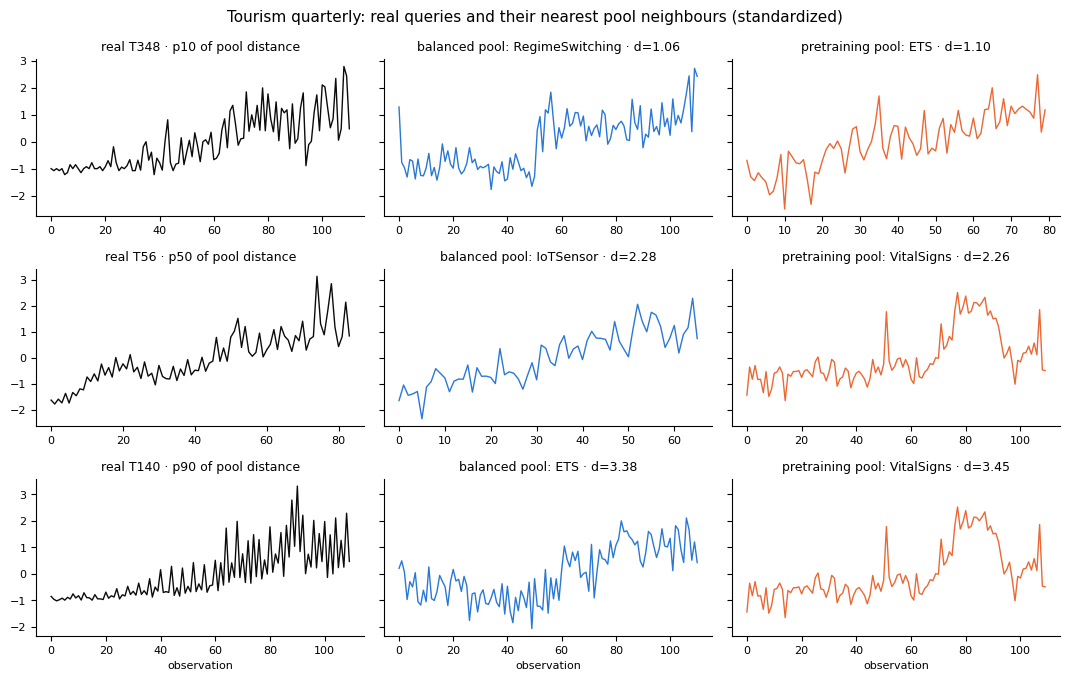

In [ ]:
plot_examples(
    "Quarterly (tourism_quarterly)", ["balanced_pool", "pretraining_pool"],
    "Tourism quarterly: real queries and their nearest pool neighbours (standardized)",
)

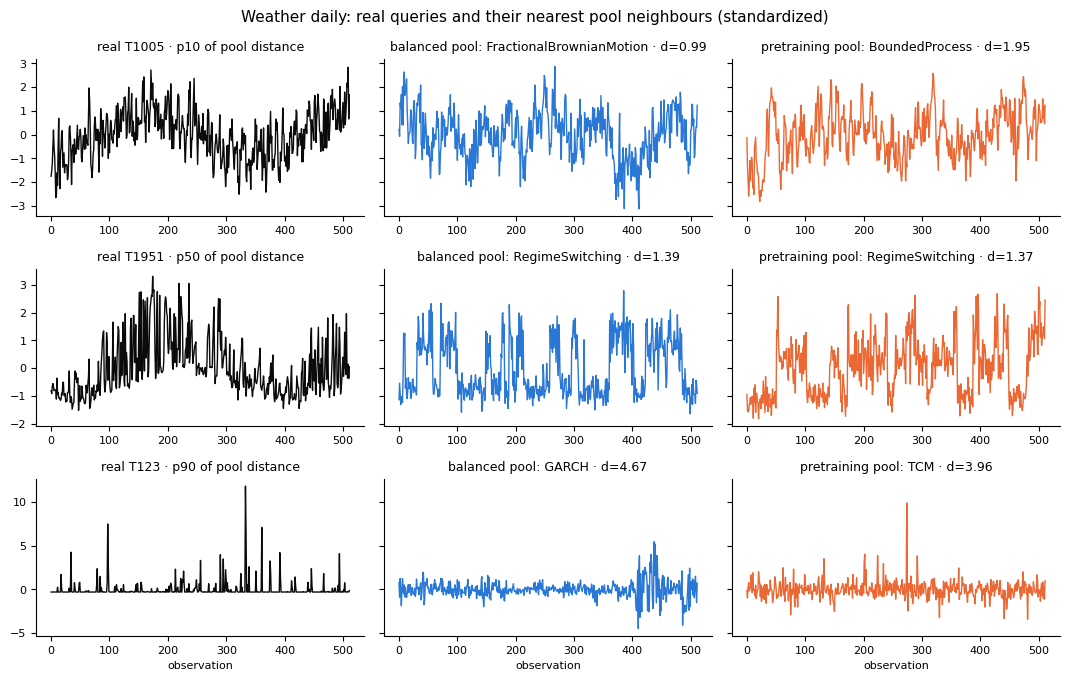

In [ ]:
plot_examples(
    "Daily (weather)", ["balanced_pool", "pretraining_pool"],
    "Weather daily: real queries and their nearest pool neighbours (standardized)",
)

The tourism series show what the seasonal-strength attribution means: a regular four-quarter cycle whose amplitude grows with a rising level. Even the closest pool neighbour, a regime-switching series with a level step, has no regular cycle, and the median and far queries are matched to sensor and vital-sign presets that only share the upward drift and the noise level. The pools contain seasonal generators, but none of the 42 prototypes produces multiplicative period-4 seasonality of this strength, so the nearest series are seasonal in the features' terms without looking seasonal.

The weather panel fails for different reasons. The two temperature-like queries carry a slow annual swing under day-to-day noise; the neighbours, a fractional Brownian motion and a regime-switching series, reproduce the roughness but not the smooth swing, and the declared weekly recipe cannot represent a cycle longer than the 512-day window. The far query is rainfall: long dry runs broken by isolated spikes, which the nearest GARCH and TCM series only resemble in being spiky. These are the two behaviours behind the Daily flag, intermittent rain and slow annual cycles, and neither is a matter of a single missing component.

## The Hourly gap

The Hourly result was replicated on fixed queries with ten fresh generation seeds and four times more candidates, then on 256 additional queries in four disjoint groups. Neither more draws nor more candidates closed it. Decomposing the nearest-neighbour distances shows that **trend strength** contributes about half of the mean squared distance: real hourly series have far stronger trend components than their nearest synthetic neighbours, whose daily cycles sit on a flat level. Omitting trend strength from the distance raises pool coverage to about 44%, so the gap is not only trend, but trend is where it starts.

To test that reading, paired diagnostic controls were generated from a unit daily sine plus noise, adding one component at a time: a slow level drift, a weekly amplitude envelope, and a second daily harmonic. The controls use no real values and share their random components within each slot, so each row below differs from the previous one by exactly one ingredient.

In [ ]:
controls = hourly["control_summary"]
existing = hourly["existing_summary"]
order = [
    ("balanced pool", existing["balanced_pool"]),
    ("pretraining pool", existing["pretraining_pool"]),
    ("cycle + noise", controls["cycle"]),
    ("+ amplitude envelope", controls["cycle_amplitude"]),
    ("+ level drift", controls["cycle_drift"]),
    ("+ drift + amplitude", controls["cycle_drift_amplitude"]),
    ("+ drift + amplitude + 2nd harmonic", controls["shape_drift_amplitude"]),
]
control_table = pd.DataFrame(
    {
        "source": label,
        "full features": row["full"]["coverage"]["median"][1],
        "omit trend strength": row["omit_trend_strength"]["coverage"]["median"][1],
        "daily-profile shape": row["profile"]["coverage"]["median"][1],
    }
    for label, row in order
).set_index("source")
real_hourly = existing["balanced_pool"]["full"]["real_baseline_coverage"]["median"][1]
control_table.style.format("{:.1%}")

,full features,omit trend strength,daily-profile shape
source,,,
balanced pool,0.8%,43.8%,68.8%
pretraining pool,1.6%,44.5%,68.8%
cycle + noise,1.6%,46.9%,67.2%
+ amplitude envelope,3.1%,50.0%,67.2%
+ level drift,57.0%,60.2%,66.4%
+ drift + amplitude,63.3%,64.8%,66.4%
+ drift + amplitude + 2nd harmonic,68.0%,68.8%,75.8%


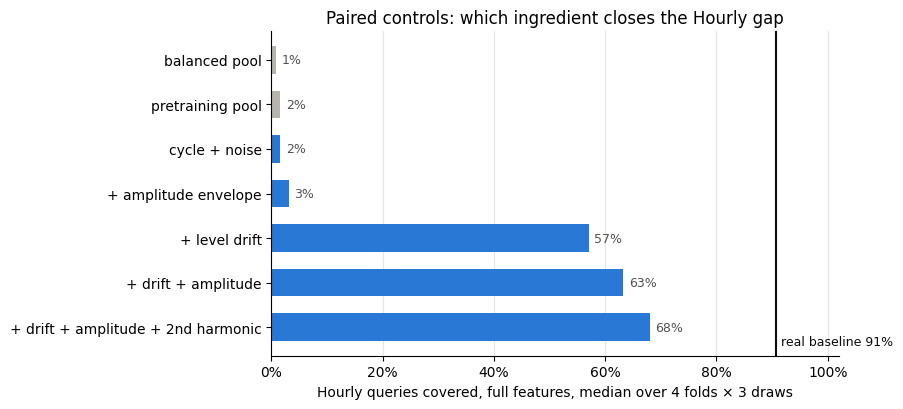

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.2))
labels = list(control_table.index)
values = control_table["full features"].to_numpy()
colors = ["#b5b4ae", "#b5b4ae"] + ["#2a78d6"] * (len(labels) - 2)
ax.barh(labels, values, color=colors, height=0.62)
for i, v in enumerate(values):
    ax.text(v + 0.01, i, f"{v:.0%}", va="center", color="#52514e", fontsize=9)
ax.axvline(real_hourly, color="#0b0b0b", linewidth=1.5)
ax.text(real_hourly + 0.01, len(labels) - 0.6, f"real baseline {real_hourly:.0%}", color="#0b0b0b", fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 1.02)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_xlabel("Hourly queries covered, full features, median over 4 folds × 3 draws")
ax.set_title("Paired controls: which ingredient closes the Hourly gap")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#e6e5e1")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Adding slow level drift to a plain daily cycle lifts full-feature coverage from 2% to 57%, and it does so in all twelve paired fold–seed comparisons. Amplitude variation alone changes little, but combined with drift it adds a few more points, and the second harmonic helps the separate daily-profile shape score. The existing pools, in grey, sit where the plain cycle does: they contain smooth daily cycles but not the combination of a daily cycle with a moving level. Real hourly series, by contrast, drift, shift, and change amplitude over a three-week window.

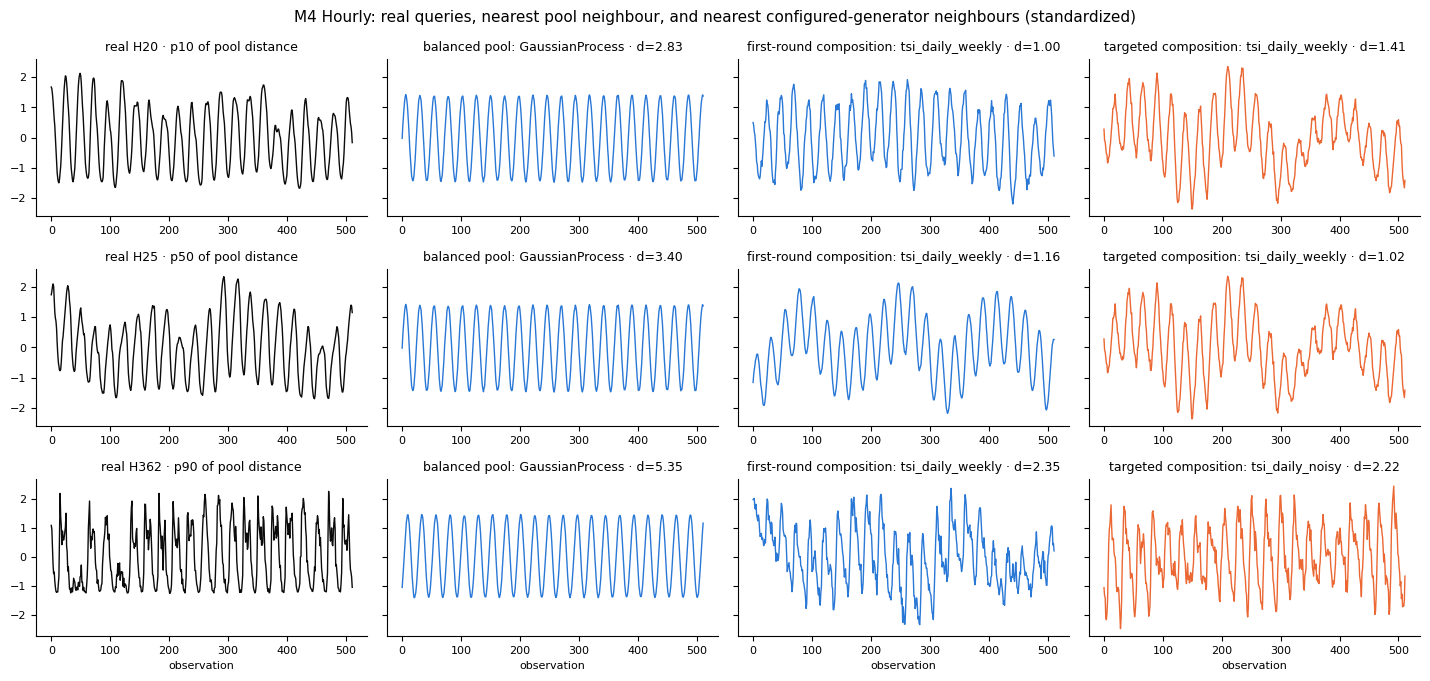

In [ ]:
plot_examples(
    "M4 Hourly", ["balanced_pool", "native_composition", "targeted_composition"],
    "M4 Hourly: real queries, nearest pool neighbour, and nearest configured-generator neighbours (standardized)",
)

For all three real queries, the nearest balanced-pool neighbour is the same periodic Gaussian-process prototype: a regular sine on a flat level. The real series drift, change amplitude from week to week, and in the 90th-percentile query have sharp, non-sinusoidal daily peaks. The first-round composition supplies daily cycles on a moving level, mostly from the daily-plus-weekly `TSIGenerator` prototype, and its neighbours share the real series' slow variation; the targeted round's noisier variant picks up the jagged query. The standardized feature distances fall from 2.8–5.4 for the pool to 1.0–2.4 for the compositions. The daily shapes remain smoother than the real ones, which is the daily-profile score the compositions did not improve.

## Can existing generators close it?

The controls are diagnostic recipes, not generators. The next question was whether the shipped classes can express the same combination through configuration alone. A benchmark-only corpus of eight prototypes was declared before inspection: `TSIGenerator` restricted to a period-24 harmonic with overtones, a slow amplitude envelope, and a drifting trend; `ETSGenerator` with multiplicative period-24 seasonality on a random-walk level; `SeasonalGenerator` with injected slope and level changepoints; and `EnergyLoadGenerator` profiles with a slope change. It was scored on the same fresh M4 splits and then on 862 hourly traffic series from the Monash repository, a panel that had not informed the design. A second, targeted round then added noisier and level-shifting variants and was scored on traffic queries never used before, with M4 kept as a retention check.

In [ ]:
first = load("feature_coverage_hourly_composition")
second = load("feature_coverage_traffic_composition")


def best_existing(agg):
    return max(agg[name]["full"]["coverage"]["median"][1] for name in COLORS if name != "real")


panels = {
    "M4 Hourly, fresh splits": (first["m4_summary"]["aggregate"], second["m4_summary"]["aggregate"]),
    "Traffic, first query set": (first["transfer_summary"]["aggregate"], None),
    "Traffic, fresh queries": (second["traffic_summary"]["aggregate"], second["traffic_summary"]["aggregate"]),
}
composition_rows = []
for label, (agg_first, agg_second) in panels.items():
    composition_rows.append(
        {
            "panel": label,
            "best existing pool": best_existing(agg_first),
            "first-round composition": agg_first["native_composition"]["full"]["coverage"]["median"][1],
            "targeted composition": (
                agg_second["targeted_composition"]["full"]["coverage"]["median"][1] if agg_second else float("nan")
            ),
            "real baseline": agg_first["balanced_pool"]["full"]["real_baseline_coverage"]["median"][1],
        }
    )
compositions = pd.DataFrame(composition_rows).set_index("panel")
compositions.style.format("{:.1%}", na_rep="—")

,best existing pool,first-round composition,targeted composition,real baseline
panel,,,,
"M4 Hourly, fresh splits",1.6%,67.2%,69.5%,90.6%
"Traffic, first query set",0.0%,10.2%,—,88.3%
"Traffic, fresh queries",0.0%,10.9%,18.8%,85.2%


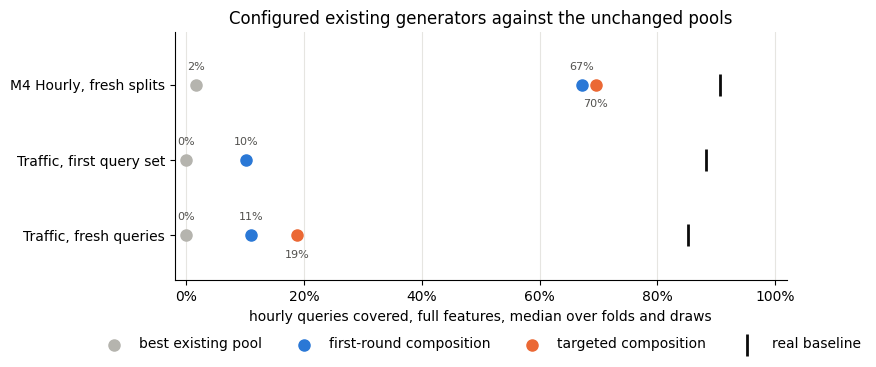

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(compositions))
series = [
    ("best existing pool", "#b5b4ae", -0.2),
    ("first-round composition", "#2a78d6", -0.2),
    ("targeted composition", "#eb6834", 0.3),
]
for label, color, text_offset in series:
    ax.scatter(compositions[label], list(y), color=color, s=64, zorder=3, label=label)
    for i, v in enumerate(compositions[label]):
        if v == v:
            ax.text(v, i + text_offset, f"{v:.0%}", ha="center", color="#52514e", fontsize=8)
ax.scatter(
    compositions["real baseline"], list(y), marker="|", s=260, color="#0b0b0b", linewidth=2,
    zorder=4, label="real baseline",
)
ax.set_yticks(list(y))
ax.set_yticklabels(compositions.index)
ax.set_ylim(len(compositions) - 0.4, -0.7)
ax.set_xlim(-0.02, 1.02)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_xlabel("hourly queries covered, full features, median over folds and draws")
ax.set_title("Configured existing generators against the unchanged pools")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#e6e5e1")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
fig.subplots_adjust(bottom=0.26, left=0.22)
plt.show()

On M4 the configured corpus reproduces the control result: 67% coverage against 1–2% for the pools, within a point of the best control, and higher than the best pool in all twelve paired comparisons. The two `TSIGenerator` prototypes supply three quarters of the nearest neighbours; the `ETSGenerator` prototypes are never nearest. It does not reproduce the controls' improvement in average daily shape.

On traffic the same corpus improves coverage in every paired comparison but only to about 10%, and the targeted second round roughly doubles that to 19% on queries never used before, while keeping the M4 result. Both rounds fall short of the declared threshold of a 25-point median gain over the best pool in three of four folds. The remaining traffic distance concerns crossing points and ten-lag autocorrelation: real traffic series combine low within-day autocorrelation with long excursions on one side of the mean, which none of the configured generators produce together.

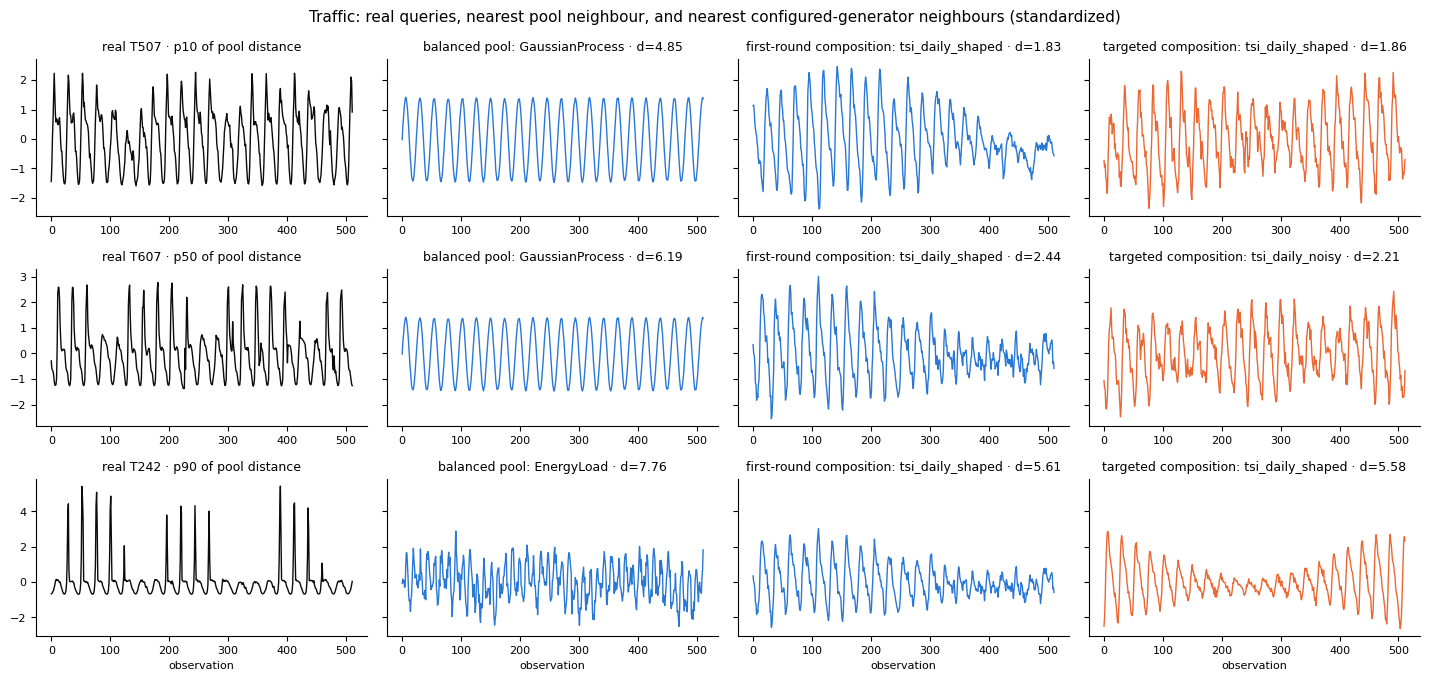

In [ ]:
plot_examples(
    "Traffic", ["balanced_pool", "native_composition", "targeted_composition"],
    "Traffic: real queries, nearest pool neighbour, and nearest configured-generator neighbours (standardized)",
)

Traffic occupancy has flat, low nights and sharp commuting peaks, so its daily shape is far from a sine, and weekend days show lower peaks. The pool neighbour is again a flat sine. The composition neighbours reproduce level changes and amplitude envelopes but not the asymmetric peak-and-floor shape; the noisy variant gets closer to the median query by adding irregularity rather than the right shape. The 90th-percentile query alternates between quiet weeks near its floor and weeks of tall spikes, and no source approaches it. This is what the remaining crossing-point and autocorrelation differences look like in the raw series: long stretches on one side of the mean, punctuated by brief excursions.

## Can configuration close the seasonal gaps?

The same approach was applied to the seasonal theme. Two benchmark-only corpora of configured `TSIGenerator`, `ETSGenerator`, and `SeasonalGenerator` instances at the panel period were scored on the two panels that motivated them, tourism quarterly and hospital monthly, and then on three panels that did not: M3 quarterly, M3 monthly, and tourism monthly. The first recipe was declared before any result and aimed at strong seasonality; it turned out far too clean, with seasonal strength near one and almost no noise, while the real series sit at moderate seasonal strength under heavy noise. The second, moderated recipe was declared after that diagnosis on the design panels only, and nothing was changed once the validation panels were scored.

In [ ]:
seasonal = load("feature_coverage_seasonal_composition")
ROLE = {"design_Quarterly": "design", "design_Monthly": "design"}
seasonal_rows = []
for key, panel in seasonal["panels"].items():
    agg = panel["summary"]
    label = {"design_Quarterly": "tourism quarterly", "design_Monthly": "hospital monthly"}.get(key, key.replace("_", " "))
    union = seasonal["augmented_pool_480"][key]
    seasonal_rows.append(
        {
            "panel": label,
            "role": panel["role"],
            "balanced pool": agg["balanced_pool"]["full"]["coverage"]["median"][1],
            "pretraining pool": agg["pretraining_pool"]["full"]["coverage"]["median"][1],
            "round 1 (strong)": agg["seasonal_composition"]["full"]["coverage"]["median"][1],
            "round 2 (moderated)": agg["moderated_seasonal_composition"]["full"]["coverage"]["median"][1],
            "real baseline": agg["balanced_pool"]["full"]["real_baseline_coverage"]["median"][1],
            "balanced + pretraining (480)": union["balanced_plus_pretraining_median_q90"],
            "balanced + round 2 (480)": union["balanced_plus_moderated_seasonal_composition"]["median_q90"],
            "paired change": union["balanced_plus_moderated_seasonal_composition"]["paired_median_change_vs_control"],
        }
    )
seasonal_table = pd.DataFrame(seasonal_rows).set_index("panel")
seasonal_table.style.format("{:.1%}", subset=[c for c in seasonal_table.columns if c != "role"])

,role,balanced pool,pretraining pool,round 1 (strong),round 2 (moderated),real baseline,balanced + pretraining (480),balanced + round 2 (480),paired change
panel,,,,,,,,,
tourism quarterly,design,46.9%,42.2%,20.3%,57.8%,91.4%,53.1%,78.1%,29.7%
hospital monthly,design,57.8%,53.9%,2.3%,45.3%,85.2%,62.5%,72.7%,7.8%
m3 quarterly,validation,82.8%,80.5%,4.7%,26.6%,86.7%,83.6%,86.7%,3.1%
m3 monthly,validation,68.0%,66.4%,3.1%,42.2%,85.9%,75.0%,84.4%,9.4%
tourism monthly,validation,10.9%,8.6%,5.5%,37.5%,85.9%,13.3%,42.2%,32.0%


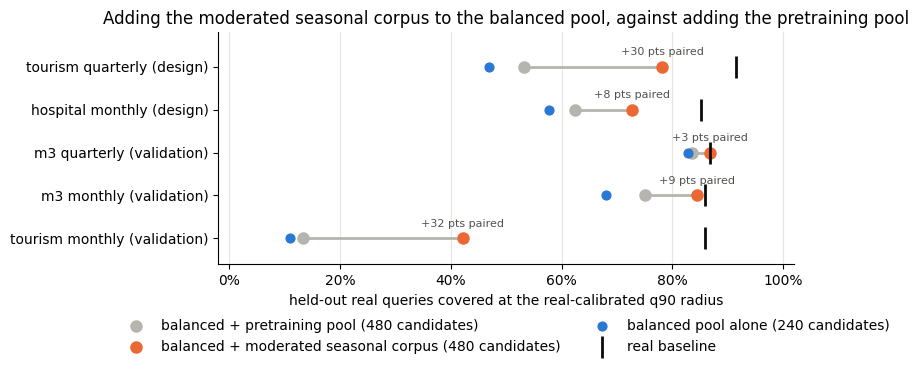

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(seasonal_table))
ax.hlines(
    list(y), seasonal_table["balanced + pretraining (480)"], seasonal_table["balanced + round 2 (480)"],
    color="#b5b4ae", linewidth=2, zorder=2,
)
ax.scatter(seasonal_table["balanced + pretraining (480)"], list(y), color="#b5b4ae", s=64, zorder=3, label="balanced + pretraining pool (480 candidates)")
ax.scatter(seasonal_table["balanced + round 2 (480)"], list(y), color="#eb6834", s=64, zorder=3, label="balanced + moderated seasonal corpus (480 candidates)")
ax.scatter(seasonal_table["balanced pool"], list(y), color="#2a78d6", s=40, zorder=3, label="balanced pool alone (240 candidates)")
ax.scatter(
    seasonal_table["real baseline"], list(y), marker="|", s=260, color="#0b0b0b", linewidth=2, zorder=4,
    label="real baseline",
)
for i, (b, change) in enumerate(zip(seasonal_table["balanced + round 2 (480)"], seasonal_table["paired change"])):
    ax.text(b, i - 0.28, f"{change * 100:+.0f} pts paired", ha="center", color="#52514e", fontsize=8)
ax.set_yticks(list(y))
ax.set_yticklabels([f"{p} ({r})" for p, r in zip(seasonal_table.index, seasonal_table["role"])])
ax.set_ylim(len(seasonal_table) - 0.4, -0.8)
ax.set_xlim(-0.02, 1.02)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_xlabel("held-out real queries covered at the real-calibrated q90 radius")
ax.set_title("Adding the moderated seasonal corpus to the balanced pool, against adding the pretraining pool")
ax.set_axisbelow(True)
ax.grid(axis="x", color="#e6e5e1")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
fig.subplots_adjust(bottom=0.3, left=0.26)
plt.show()

Scored as a **replacement** for the pools, the moderated corpus fails the declared 25-point criterion on every validation panel: it beats the pools on the two tourism panels but, being narrow, covers far fewer queries than they do on the broad M3 panels. That criterion answers the wrong question for a corpus meant to fill a gap. The question a preset change poses is whether **adding** the corpus helps, so the chart compares the balanced pool plus the moderated corpus with the balanced pool plus the pretraining pool, both at 480 candidates and the same real-calibrated radius. The addition is ahead on all five panels, by 3 points where the pools were already near the baseline and by about 30 points on the tourism panels, and higher in 53 of 60 fold–seed pairs. This comparison was specified after the replacement results were known, so it is a post-hoc analysis and is labelled as such in the benchmark report; the three validation panels were nevertheless never used to tune the recipe.

Tourism monthly, one of the held-out panels, is itself a new finding: the pools cover 11% of its queries against an 86% real baseline. The examples below show why, and what the moderated corpus adds.

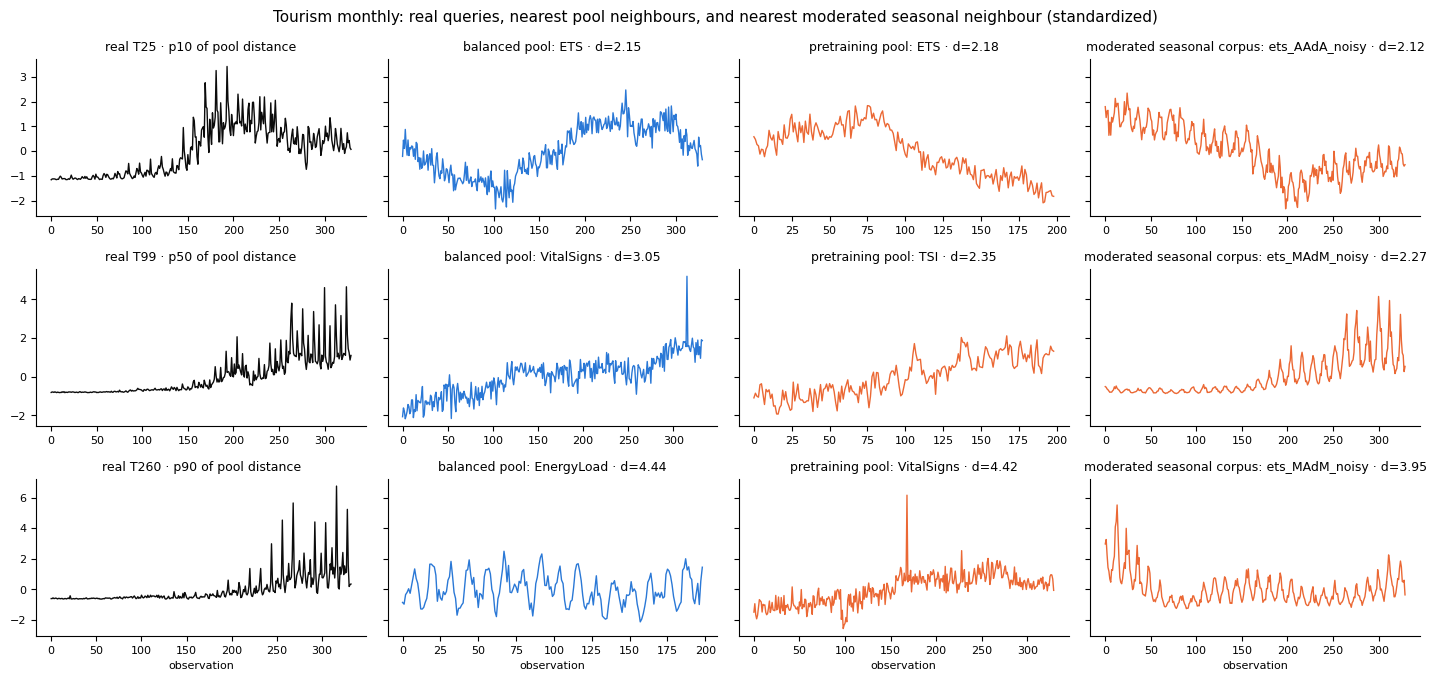

In [ ]:
plot_examples(
    "Monthly (tourism_monthly)", ["balanced_pool", "pretraining_pool", "moderated_seasonal_composition"],
    "Tourism monthly: real queries, nearest pool neighbours, and nearest moderated seasonal neighbour (standardized)",
)

Real tourism series carry a strong twelve-month cycle whose amplitude grows with the level, on a trend with occasional level shifts. The pools' nearest neighbours are Holt-Winters ETS series with a much weaker cycle, or physiological and load presets that only share the noise texture. The moderated corpus supplies noisy Holt-Winters and sine-with-breaks series with a visible cycle, drawn roughly equally from its additive, multiplicative, and level-break prototypes, and those become the nearest neighbours. Its distances are still not small, and seasonal strength remains the largest remaining difference: the corpus narrows the gap rather than closing it.

### The shipped preset and its pre-declared test

The moderated corpus now ships as the opt-in `seasonal_pool()` preset, with exactly the configuration benchmarked above. Because the augmented comparison had been chosen after the fact, it was declared as the criterion **before** testing the preset on four panels never used in any earlier step: fresh M4 Quarterly and Monthly samples, M1 monthly, and intermittent car-parts sales as a no-harm check. The gates were a median paired gain of at least 5 points in three of four folds, and no fold below −2 points, for balanced + preset against balanced + pretraining at 480 candidates each.

In [ ]:
preset = load("feature_coverage_seasonal_preset")
preset_rows = []
for key, panel in preset["panels"].items():
    agg = panel["summary"]
    union = panel["union_summary"]
    three = preset["post_hoc_three_way_union_720"][key]
    preset_rows.append(
        {
            "panel": key.replace("_", " "),
            "balanced pool": agg["balanced_pool"]["full"]["coverage"]["median"][1],
            "preset alone": agg["seasonal_pool"]["full"]["coverage"]["median"][1],
            "real baseline": agg["balanced_pool"]["full"]["real_baseline_coverage"]["median"][1],
            "balanced + pretraining (480)": union["balanced_plus_pretraining_pool"]["median"],
            "balanced + preset (480)": union["balanced_plus_seasonal_pool"]["median"],
            "paired change": union["paired_change"]["median"],
            "gain gate": "pass" if panel["criterion"]["gain"] else "fail",
            "no-harm gate": "pass" if panel["criterion"]["no_harm"] else "fail",
            "on top of both pools vs + MAR (720)": three["paired_median_change_vs_plus_mar"],
        }
    )
preset_table = pd.DataFrame(preset_rows).set_index("panel")
preset_table.style.format("{:.1%}", subset=[c for c in preset_table.columns if "gate" not in c])

,balanced pool,preset alone,real baseline,balanced + pretraining (480),balanced + preset (480),paired change,gain gate,no-harm gate,on top of both pools vs + MAR (720)
panel,,,,,,,,,
m4 quarterly fresh,78.1%,32.8%,84.4%,84.4%,81.2%,0.0%,fail,fail,1.6%
m4 monthly fresh,89.1%,56.2%,94.5%,91.4%,96.9%,2.3%,fail,pass,3.9%
m1 monthly,66.4%,66.4%,90.6%,76.6%,89.8%,12.5%,pass,pass,7.8%
car parts,43.8%,21.1%,85.2%,50.0%,46.9%,-3.1%,fail,fail,-0.8%


The verdict is mixed and is reported as such. M1 monthly, where the pools sit 24 points below the real baseline, passes both gates with a 12.5-point paired gain and is the only clear pass. The two fresh M4 samples have no seasonal gap to fill and come out neutral, though M4 Quarterly misses the no-harm gate by one point in one fold. Car parts fails no-harm: its gap is an intermittent-demand gap that the seasonal preset does not address, while the pretraining pool's meta-generators help a little, so displacing their share costs 3 points. Added on top of both pools rather than in place of a share, a post-hoc comparison against adding random MAR shows the preset never hurts and helps where seasonality is strong. That is how the preset is documented: an opt-in addition on top of a pool, kept out of the defaults.

A last pre-declared test asked whether the addition should become the `pretraining_pool` default, through the new `include_seasonal` flag, by comparing the pool with and without it as equal-count corpora on fifteen panels at every frequency but yearly. The flag raised coverage on every quarterly and monthly panel, by 2 to 14 points, and lowered it by 3 to 6 points on weekly, daily, and intermittent panels, where it builds a cycle those series do not have and displaces breadth. Six panels failed the no-harm gate, so the default stays off, and the flag is recommended for quarterly and monthly targets only. The table below is from that run.

In [ ]:
default_test = load("feature_coverage_pretraining_seasonal_default")
default_rows = []
for key, panel in default_test["panels"].items():
    agg = panel["summary"]
    default_rows.append(
        {
            "panel": key.replace("_", " "),
            "frequency": panel["group"],
            "without flag": agg["pretraining_pool"]["full"]["coverage"]["median"][1],
            "with flag": agg["pretraining_pool_with_seasonal"]["full"]["coverage"]["median"][1],
            "real baseline": agg["pretraining_pool"]["full"]["real_baseline_coverage"]["median"][1],
            "paired change": panel["paired_change_summary"]["median"],
            "no-harm gate": "pass" if panel["criterion"]["no_harm"] else "fail",
            "gain gate": "pass" if panel["criterion"]["gain"] else "fail",
        }
    )
default_table = pd.DataFrame(default_rows).set_index("panel")
default_table.style.format("{:.1%}", subset=["without flag", "with flag", "real baseline", "paired change"])

,frequency,without flag,with flag,real baseline,paired change,no-harm gate,gain gate
panel,,,,,,,
m4 quarterly,Quarterly,77.3%,84.4%,88.3%,1.6%,fail,fail
m4 monthly,Monthly,73.4%,82.8%,91.4%,6.2%,pass,fail
m4 weekly,Weekly,74.2%,71.9%,93.0%,-5.5%,fail,fail
m4 daily,Daily,43.0%,42.2%,89.1%,-4.7%,fail,fail
m4 hourly,Hourly,0.8%,2.3%,85.9%,0.8%,pass,fail
tourism quarterly,Quarterly,46.9%,65.6%,89.1%,10.2%,pass,pass
hospital,Monthly,61.7%,65.6%,89.8%,2.3%,pass,fail
traffic weekly,Weekly,72.7%,71.9%,88.3%,-0.8%,fail,fail
weather,Daily,47.7%,46.1%,89.8%,0.0%,fail,fail


## What this means for the presets

::: {.callout-important}
## Recommendation

- **Keep the production pools as they are for now.** The two pools are interchangeable for coverage, and no single configuration has yet been shown to close a gap on a panel that did not inform it, so there is no evidence-backed change to `interpretable_pool` or `pretraining_pool` defaults.
- **The gap is about strong regular seasonality on a moving level, not one frequency.** Within M4 only Hourly is short, but tourism quarterly and monthly, hospital monthly, and weather daily are also under-covered on independent panels.
- **Ship gap-filling corpora as opt-in additions, not replacements.** `seasonal_pool()` is now available for that purpose: it raised coverage on tourism, hospital, and M1 monthly panels, was neutral on M4, and gave nothing on intermittent data, so it belongs on top of a pool and outside the defaults. A comparable hourly preset would need the same pre-declared test on a third hourly panel first.
- **Evaluate on held-out panels, not M4 alone.** M4 Quarterly looked covered at 88% while tourism quarterly is at 47%; a benchmark on one source can miss a gap that another source shows.
:::

::: {.callout-warning}
## What coverage does not tell you

- Coverage is conditional on the twelve `native_v1` features, standardized Euclidean distance, a q90 radius, and the declared period and window per panel. Manhattan distance and feature omissions shift absolute levels by up to ten points, and by far more on Hourly.
- Fold–seed measurements share real series across roles and are not independent replications; there are no confidence intervals in these summaries.
- A covered query has a synthetic neighbour with similar summaries, not a similar series. Nothing here measures forecasting accuracy, raw-series distance, or privacy.
:::

## Reproduce

The benchmarks run in sequence, each reading the previous one's committed `summary.json`. Detailed per-query traces are written next to the summaries and are gitignored; the READMEs in each directory document protocol, results, and limits.

```bash
# schema pilot, corroboration, availability audit, six-frequency smoke run
python benchmarks/benchmark_feature_coverage.py --download
python benchmarks/validate_feature_coverage.py
python benchmarks/benchmark_feature_coverage.py --availability-only
python benchmarks/benchmark_feature_coverage.py --smoke

# Hourly: investigation, fresh splits with paired controls, two composition rounds
python benchmarks/investigate_hourly_coverage.py
python benchmarks/validate_hourly_splits.py
python benchmarks/validate_hourly_composition.py --download
python benchmarks/validate_traffic_composition.py

# all other frequencies, three seeds and four fresh query groups, on M4 and on Monash panels
python benchmarks/benchmark_cross_frequency.py
python benchmarks/benchmark_third_panels.py --download

# seasonal-strength composition with held-out validation panels
python benchmarks/validate_seasonal_composition.py --download
python benchmarks/validate_seasonal_preset.py --download
python benchmarks/validate_pretraining_seasonal_default.py --download

# raw example series plotted on this page
python benchmarks/export_coverage_examples.py
```

Summaries live under `benchmarks/data/feature_coverage_*/`. The API used above, `compute_features` and `compare_feature_coverage`, is documented in the [evaluation reference](../../evaluation).